This notebook uses the Aposemat IoT-23 dataset.

*Sebastian Garcia, Agustin Parmisano, & Maria Jose Erquiaga. (2020). IoT-23: A labeled dataset with malicious and benign IoT network traffic (Version 1.0.0) [Data set]. Zenodo. http://doi.org/10.5281/zenodo.4743746*

More specifically, a preprocessed version which combines around 6 million samples from this dataset into one singular csv file.

## 1. Import Libraries

In [53]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import m2cgen as m2c

In [2]:
# Seaborn configuration
sns.set_context("paper", font_scale=1.2)
sns.set_style("white")

## 2. Load dataset

In [3]:
dataset = Path("data/iot23.parquet")
df_raw = pd.read_parquet(dataset)

In [4]:
df = df_raw.copy()
df.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,conn_state,local_orig,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,label
0,1.536227e+09,CeqqKl3hyLQmO8LK98,192.168.100.111,17576.0,78.1.220.212,8081.0,tcp,-,3e-06,0,...,S0,-,-,0.0,S,2.0,80.0,0.0,0.0,PartOfAHorizontalPortScan
1,1.536227e+09,C2oHQWo1EFGH8D9x7,192.168.100.111,17576.0,152.84.7.111,8081.0,tcp,-,2e-06,0,...,S0,-,-,0.0,S,2.0,80.0,0.0,0.0,PartOfAHorizontalPortScan
2,1.536227e+09,CJLVjs4BByG04mczXc,192.168.100.111,17576.0,173.36.41.67,8081.0,tcp,-,2e-06,0,...,S0,-,-,0.0,S,2.0,80.0,0.0,0.0,PartOfAHorizontalPortScan
3,1.536227e+09,C0z4uS9AWHDH2s4S7,192.168.100.111,17576.0,87.13.21.104,8081.0,tcp,-,2e-06,0,...,S0,-,-,0.0,S,2.0,80.0,0.0,0.0,PartOfAHorizontalPortScan
4,1.536227e+09,CxbNVk3liFNUIlqSPi,192.168.100.111,17576.0,99.110.163.140,8081.0,tcp,-,2e-06,0,...,S0,-,-,0.0,S,2.0,80.0,0.0,0.0,PartOfAHorizontalPortScan


## 3. EDA

In [5]:
# Define a function to drop columns that have only one unique value
def drop_constant_columns(df):
    constant_columns = [col for col in df.columns if df[col].nunique() == 1]
    df.drop(columns=constant_columns, inplace=True)

drop_constant_columns(df)

Remove IP columns, history and UID.

In [6]:
df.drop(columns=['id.orig_h', 'id.resp_h', 'history', 'uid'], inplace=True)

Rename columns

In [7]:
df.rename(columns={
    "ts": "timestamp",
    "id.orig_p": "source_port",
    "id.resp_p": "dest_port",
    "proto": "protocol",
    "orig_bytes": "payload_bytes_sent_from_source",
    "resp_bytes": "payload_bytes_sent_from_dest",
    "conn_state": "connection_state",
    "orig_pkts": "packets_sent_from_source",
    "resp_pkts": "packets_sent_from_dest",
    "orig_ip_bytes": "ip_bytes_sent_from_source",
    "resp_ip_bytes": "ip_bytes_sent_from_dest"
}, inplace=True)

In [8]:
list(df)

['timestamp',
 'source_port',
 'dest_port',
 'protocol',
 'service',
 'duration',
 'payload_bytes_sent_from_source',
 'payload_bytes_sent_from_dest',
 'connection_state',
 'missed_bytes',
 'packets_sent_from_source',
 'ip_bytes_sent_from_source',
 'packets_sent_from_dest',
 'ip_bytes_sent_from_dest',
 'label']

Plot protocol frequency

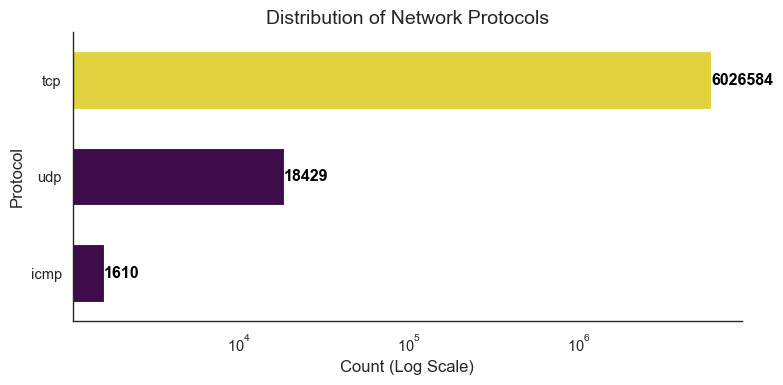

In [9]:
protocol_counts = df['protocol'].value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=protocol_counts.values, y=protocol_counts.index, width=0.6, hue=protocol_counts.values, palette='viridis', legend=False)
sns.despine(top=True, right=True)
plt.title('Distribution of Network Protocols', fontsize=14)
plt.xlabel('Count (Log Scale)', fontsize=12)
plt.ylabel('Protocol', fontsize=12)
plt.xscale('log')

for i, v in enumerate(protocol_counts.values):
    plt.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('graphs/protocol_bar_chart.pdf', dpi=300, bbox_inches='tight')

Plot label frequencies

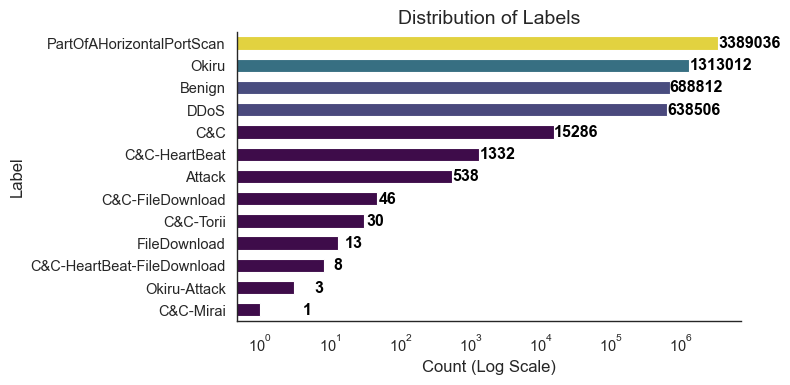

In [10]:
label_counts = df['label'].value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=label_counts.values, y=label_counts.index, width=0.6, hue=label_counts.values, palette='viridis', legend=False)
sns.despine(top=True, right=True)
plt.title('Distribution of Labels', fontsize=14)
plt.xlabel('Count (Log Scale)', fontsize=12)
plt.ylabel('Label', fontsize=12)
plt.xscale('log')

for i, v in enumerate(label_counts.values):
    plt.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('graphs/label_bar_chart.pdf', dpi=300, bbox_inches='tight')

## 4. Feature Engineering

Convert labels into boolean values. True for attack, False for benign.

In [11]:
df['is_attack'] = np.where(df['label'] == 'Benign', 0, 1).astype(bool)
df = df.drop(columns=['label'])
df['is_attack'].value_counts()

is_attack
True     5357811
False     688812
Name: count, dtype: int64

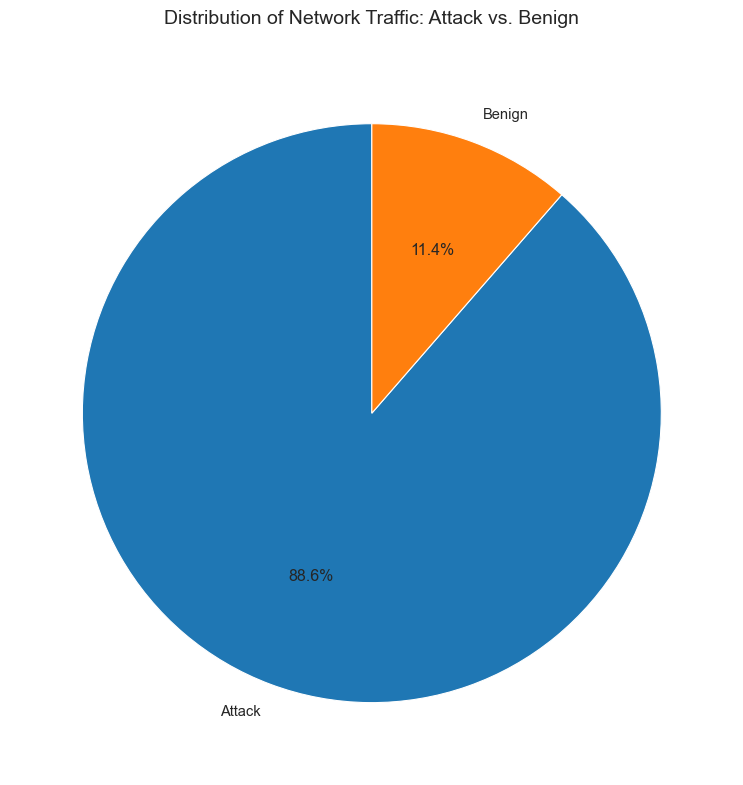

In [12]:
plt.figure(figsize=(8, 8))
plt.pie(
    df['is_attack'].value_counts(),
    labels=['Attack', 'Benign'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Network Traffic: Attack vs. Benign', fontsize=14, pad=20)

plt.tight_layout()
plt.savefig('graphs/attack_benign_distribution.pdf', dpi=300, bbox_inches='tight')
plt.show()

Change data types of features

In [13]:
print(df.dtypes)

timestamp                         float64
source_port                       float64
dest_port                         float64
protocol                              str
service                               str
duration                              str
payload_bytes_sent_from_source        str
payload_bytes_sent_from_dest          str
connection_state                      str
missed_bytes                      float64
packets_sent_from_source          float64
ip_bytes_sent_from_source         float64
packets_sent_from_dest            float64
ip_bytes_sent_from_dest           float64
is_attack                            bool
dtype: object


In [14]:
# List the columns that should be numbers but are currently 'str'
numeric_cols = [
    'duration',
    'payload_bytes_sent_from_source',
    'payload_bytes_sent_from_dest'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill the new NaNs with 0
df[numeric_cols] = df[numeric_cols].fillna(0)

In [15]:
# List of columns that should be whole numbers
int_cols = [
    'source_port', 'dest_port', 'missed_bytes',
    'packets_sent_from_source', 'packets_sent_from_dest',
    'payload_bytes_sent_from_source', 'payload_bytes_sent_from_dest',
    'ip_bytes_sent_from_source', 'ip_bytes_sent_from_dest'
]

df[int_cols] = df[int_cols].astype('Int64')

In [16]:
# List of columns that should be categorical
cat_cols = ['protocol', 'service', 'connection_state']

for col in cat_cols:
    df[col] = df[col].astype('category')

Create Inter-Arrival-Time (IAT) feature

In [17]:
df["inter_arrival_time"] = df["timestamp"].diff().fillna(0)
df.drop(columns=["timestamp"], inplace=True)
df.head()

,source_port,dest_port,protocol,service,duration,payload_bytes_sent_from_source,payload_bytes_sent_from_dest,connection_state,missed_bytes,packets_sent_from_source,ip_bytes_sent_from_source,packets_sent_from_dest,ip_bytes_sent_from_dest,is_attack,inter_arrival_time
0,17576,8081,tcp,-,0.000003,0,0,S0,0,2,80,0,0,True,0.000000
1,17576,8081,tcp,-,0.000002,0,0,S0,0,2,80,0,0,True,0.000005
2,17576,8081,tcp,-,0.000002,0,0,S0,0,2,80,0,0,True,0.000004
3,17576,8081,tcp,-,0.000002,0,0,S0,0,2,80,0,0,True,0.000012
4,17576,8081,tcp,-,0.000002,0,0,S0,0,2,80,0,0,True,0.000004


Create avg packet size features

In [18]:
df['avg_packet_size_source'] = (df['ip_bytes_sent_from_source'] / df['packets_sent_from_source']).replace([np.inf, -np.inf], 0).fillna(0)
df['avg_packet_size_dest'] = (df['ip_bytes_sent_from_dest'] / df['packets_sent_from_dest']).replace([np.inf, -np.inf], 0).fillna(0)

Create throughput feature

In [19]:
df['throughput'] = (df['ip_bytes_sent_from_source'] / df['duration']).replace([np.inf, -np.inf], 0).fillna(0)

Create packet ratio feature

In [20]:
df['packet_ratio'] = (df['packets_sent_from_source'] / df['packets_sent_from_dest']).replace([np.inf, -np.inf], 0).fillna(0)

Create byte ratio feature

In [21]:
df['byte_ratio'] = (df['payload_bytes_sent_from_source'] / df['payload_bytes_sent_from_dest']).replace([np.inf, -np.inf], 0).fillna(0)

One-hot encode catagorical features

In [22]:
# Select the categorical columns
categorical_cols = ['protocol', 'service', 'connection_state']

# This will transform them into multiple 0/1 columns
df = pd.get_dummies(df, columns=categorical_cols)

In [23]:
# Convert everything to standard floats
df = df.astype(float)

In [24]:
df.head()

,source_port,dest_port,duration,payload_bytes_sent_from_source,payload_bytes_sent_from_dest,missed_bytes,packets_sent_from_source,ip_bytes_sent_from_source,packets_sent_from_dest,ip_bytes_sent_from_dest,...,connection_state_RSTOS0,connection_state_RSTR,connection_state_RSTRH,connection_state_S0,connection_state_S1,connection_state_S2,connection_state_S3,connection_state_SF,connection_state_SH,connection_state_SHR
0,17576.0,8081.0,0.000003,0.0,0.0,0.0,2.0,80.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17576.0,8081.0,0.000002,0.0,0.0,0.0,2.0,80.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,17576.0,8081.0,0.000002,0.0,0.0,0.0,2.0,80.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,17576.0,8081.0,0.000002,0.0,0.0,0.0,2.0,80.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,17576.0,8081.0,0.000002,0.0,0.0,0.0,2.0,80.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
# Replace any remaining hidden inf values with 0
df = df.replace([np.inf, -np.inf], 0)

# Fill any remaining NaNs with 0
df = df.fillna(0)

## 5. Preprocessing

Downsample the dataset from roughly six million samples to 100,000.

In [26]:
df_attack = df[df['is_attack'] == 1].sample(n=50_000, random_state=42)
df_normal = df[df['is_attack'] == 0].sample(n=50_000, random_state=42)
df_balanced = pd.concat([df_attack, df_normal]).sample(frac=1, random_state=42)

Split the data into training and test tests

In [27]:
X = df_balanced.drop(columns=['is_attack'])
y = df_balanced['is_attack']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Scale values

In [28]:
# Fit scaler on train only, transform both
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Training

Train base model

In [29]:
rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 7. Evaluation

In [30]:
print(f"Number of features: {len(X.columns)}")

Number of features: 39


Evaluate the base model

In [31]:
y_pred = rf_base.predict(X_test_scaled)
print("--- Base RF Model Classification Report ---")
print(classification_report(y_test, y_pred))

--- Base RF Model Classification Report ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     10000
         1.0       1.00      1.00      1.00     10000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



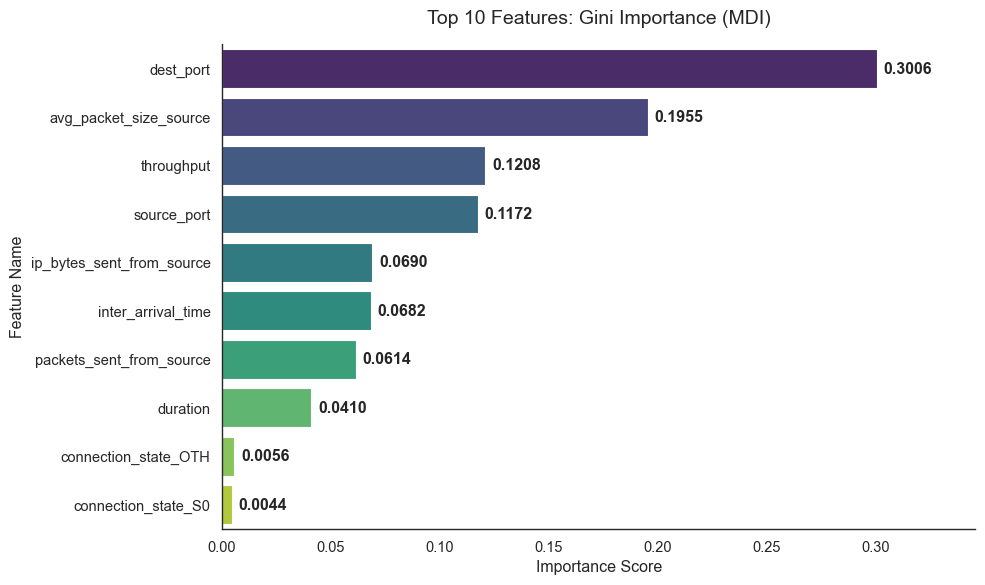

In [35]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_base.feature_importances_
})

# MDI importance plot
top_10_mdi = feature_importance.sort_values('importance', ascending=False).reset_index(drop=True).head(10)

plt.figure(figsize=(10, 6))
ax1 = sns.barplot(
    data=top_10_mdi,
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False
)
sns.despine()

for i, v in enumerate(top_10_mdi['importance']):
    ax1.text(v + (top_10_mdi['importance'].max() * 0.01), i, f'{v:.4f}',
             va='center', fontweight='semibold')

plt.title("Top 10 Features: Gini Importance (MDI)", fontsize=14, pad=15)
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.xlim(0, top_10_mdi['importance'].max() * 1.15)

plt.tight_layout()
plt.savefig('graphs/feature_importance_mdi.pdf', bbox_inches='tight')
plt.show()

Calculating Permutation Importance


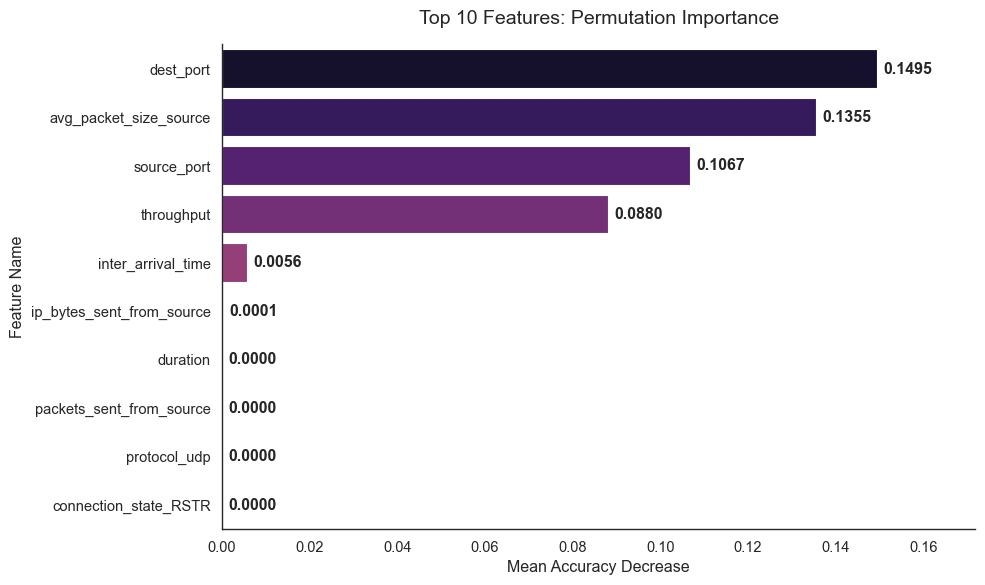


Meaningful Features (Permutation > 0.001):
['dest_port', 'avg_packet_size_source', 'source_port', 'throughput', 'inter_arrival_time']


In [36]:
# Permutation Importance Plot (More Reliable)
print("Calculating Permutation Importance")
perm = permutation_importance(rf_base, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1)

perm_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

top_10_perm = perm_importance.head(10)

plt.figure(figsize=(10, 6))
ax2 = sns.barplot(
    data=top_10_perm,
    x='importance',
    y='feature',
    hue='feature',
    palette='magma',
    legend=False
)
sns.despine()

for i, v in enumerate(top_10_perm['importance']):
    ax2.text(v + (top_10_perm['importance'].max() * 0.01), i, f'{v:.4f}',
             va='center', fontweight='semibold')

plt.title("Top 10 Features: Permutation Importance", fontsize=14, pad=15)
plt.xlabel("Mean Accuracy Decrease")
plt.ylabel("Feature Name")
plt.xlim(0, top_10_perm['importance'].max() * 1.15)

plt.tight_layout()
plt.savefig('graphs/feature_importance_permutation.pdf', bbox_inches='tight')
plt.show()

print("\nMeaningful Features (Permutation > 0.001):")
meaningful_features = perm_importance[perm_importance['importance'] > 0.001]
print(meaningful_features['feature'].tolist())

Select the top features

In [52]:
0# Create dataframe containing only meaningful features
X_meaningful = df_balanced[meaningful_features['feature'].tolist()]
y_meaningful = df_balanced['is_attack']

X_meaningful.head()

,dest_port,avg_packet_size_source,source_port,throughput,inter_arrival_time
211532,23.0,40.0,54580.0,0.000000,0.000218
287882,23.0,60.0,60172.0,0.000000,0.000003
336469,37215.0,40.0,5526.0,0.000000,0.000250
69605,23.0,60.0,46648.0,0.000000,0.000223
457331,23.0,60.0,52034.0,57.999145,0.000493


In [37]:
# Split
X_train_meaningful, X_test_meaningful, y_train_meaningful, y_test_meaningful = train_test_split(
    X_meaningful, y_meaningful, test_size=0.2, random_state=42, stratify=y_meaningful
)

# Scale
scaler_meaningful = RobustScaler()
X_train_meaningful_scaled = scaler_meaningful.fit_transform(X_train_meaningful)
X_test_meaningful_scaled = scaler_meaningful.transform(X_test_meaningful)

# Train using 100 trees
rf_meaningful = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_meaningful.fit(X_train_meaningful_scaled, y_train_meaningful)

# Evaluate to prove no major loss in accuracy
y_pred_meaningful = rf_meaningful.predict(X_test_meaningful_scaled)
print("--- 5-Feature Performance ---")
print(classification_report(y_test_meaningful, y_pred_meaningful))

--- 5-Feature Performance ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     10000
         1.0       1.00      1.00      1.00     10000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



Even with only five features, reduced down from thirty-nine. The model still performs well with perfect scores.

Plot confusion matrix for the RF model using only the five most important features

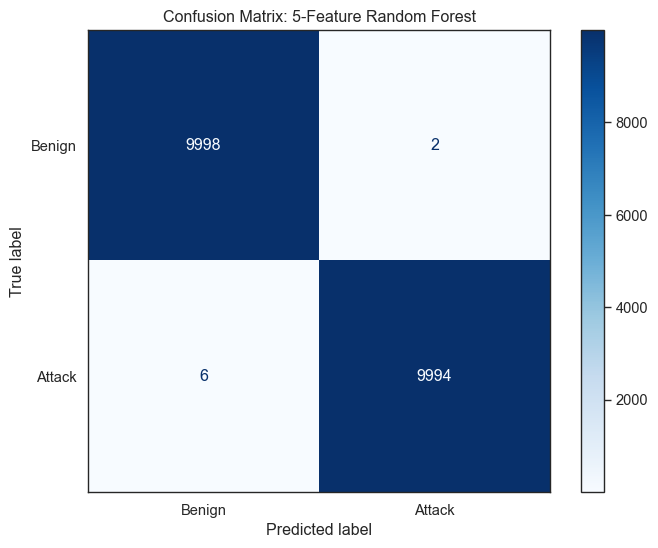

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_meaningful,
    y_pred_meaningful,
    display_labels=['Benign', 'Attack'],
    cmap='Blues',
    ax=ax
)
plt.title("Confusion Matrix: 5-Feature Random Forest")
plt.show()

Save the model

In [39]:
# Save the model and scaler
joblib.dump(rf_meaningful, 'models/random_forest_iot23.joblib')
joblib.dump(scaler_meaningful, 'models/scaler_iot23.joblib')

# Check file size in KB
size_kb = os.path.getsize('models/random_forest_iot23.joblib') / 1024
print(f"Random Forest Model Size: {size_kb:.2f} KB")

Random Forest Model Size: 2366.76 KB


## 8. Optimisation

Currently, the model size is ~2400KB. This is too large for the ESP32 512KB RAM.

In [40]:
# Create a small loop to test combinations
for trees in [5, 10]:
    for depth in [3, 4, 5, 6, 7, 8, 9, 10]:
        test_rf = RandomForestClassifier(n_estimators=trees, max_depth=depth, random_state=42)
        test_rf.fit(X_train_meaningful_scaled, y_train_meaningful)
        acc = test_rf.score(X_test_meaningful_scaled, y_test_meaningful)

        # Export to see C++ line count (roughly)
        temp_code = m2c.export_to_c(test_rf)
        lines = len(temp_code.split('\n'))

        print(f"Trees: {trees} | Depth: {depth} | Accuracy: {acc:.4f} | Est. C++ Lines: {lines}")

Trees: 5 | Depth: 3 | Accuracy: 0.9680 | Est. C++ Lines: 173
Trees: 5 | Depth: 4 | Accuracy: 0.9692 | Est. C++ Lines: 309
Trees: 5 | Depth: 5 | Accuracy: 0.9786 | Est. C++ Lines: 513
Trees: 5 | Depth: 6 | Accuracy: 0.9838 | Est. C++ Lines: 781
Trees: 5 | Depth: 7 | Accuracy: 0.9854 | Est. C++ Lines: 981
Trees: 5 | Depth: 8 | Accuracy: 0.9871 | Est. C++ Lines: 1173
Trees: 5 | Depth: 9 | Accuracy: 0.9943 | Est. C++ Lines: 1393
Trees: 5 | Depth: 10 | Accuracy: 0.9953 | Est. C++ Lines: 1545
Trees: 10 | Depth: 3 | Accuracy: 0.9680 | Est. C++ Lines: 333
Trees: 10 | Depth: 4 | Accuracy: 0.9687 | Est. C++ Lines: 605
Trees: 10 | Depth: 5 | Accuracy: 0.9721 | Est. C++ Lines: 985
Trees: 10 | Depth: 6 | Accuracy: 0.9837 | Est. C++ Lines: 1481
Trees: 10 | Depth: 7 | Accuracy: 0.9867 | Est. C++ Lines: 1941
Trees: 10 | Depth: 8 | Accuracy: 0.9882 | Est. C++ Lines: 2325
Trees: 10 | Depth: 9 | Accuracy: 0.9948 | Est. C++ Lines: 3041
Trees: 10 | Depth: 10 | Accuracy: 0.9969 | Est. C++ Lines: 3437


Using five trees produces relatively similar accuracies compared to ten trees, while also being smaller in estimated C++ lines.
A depth of 9 offers a significant enough boost compared to a depth of 8, which makes it worth the added C++ code. Whereas a depth of 10 only adds extra ~0.1% accuracy, so the trade-off between memory and accuracy does not seem worth it for a depth of 10. Therefore, a model using five trees with depth 9 will be used.

In [45]:
# Create the model with the optimised parameters
rf_optimised = RandomForestClassifier(n_estimators=5, max_depth=9, random_state=42)

# Create the pipeline for Cross-Validation
cv_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('rf_optimised', RandomForestClassifier(n_estimators=5, max_depth=9, random_state=42))
])

# Perform Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_pipeline, X_train_meaningful, y_train_meaningful, cv=kf)

print("--- Cross-Validation Results ---")
print(f"Individual Fold Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean()*100:.2f}%")
print(f"Stability (Std Dev): {cv_scores.std():.4f}")

# Overfitting Check (Train vs Test)
rf_optimised.fit(X_train_meaningful_scaled, y_train_meaningful)
train_acc = rf_optimised.score(X_train_meaningful_scaled, y_train_meaningful)
test_acc = rf_optimised.score(X_test_meaningful_scaled, y_test_meaningful)

print("\n--- Generalization Check ---")
print(f"Training Accuracy: {train_acc*100:.2f}%")
print(f"Testing Accuracy: {test_acc*100:.2f}%")
print(f"The 'Gap': {(train_acc - test_acc)*100:.4f}%")

if (train_acc - test_acc) > 0.02:
    print("WARNING: Model may be overfitting (Gap > 2%)")
else:
    print("SUCCESS: Model generalizes well to unseen data.")

# Check Size
joblib.dump(rf_optimised, 'models/rf_optimised.joblib')
optimised_size_kb = os.path.getsize('models/rf_optimised.joblib') / 1024
print(f"\nSize of optimised RF: {optimised_size_kb:.2f} KB")

--- Cross-Validation Results ---
Individual Fold Scores: [0.9946875 0.98875   0.9939375 0.9915    0.9846875]
Mean Accuracy: 99.07%
Stability (Std Dev): 0.0037

--- Generalization Check ---
Training Accuracy: 99.50%
Testing Accuracy: 99.43%
The 'Gap': 0.0688%
SUCCESS: Model generalizes well to unseen data.

Size of optimised RF: 56.90 KB


--- Optimised RF (5 Trees, Depth 9) Performance ---
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     10000
         1.0       1.00      0.99      0.99     10000

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000



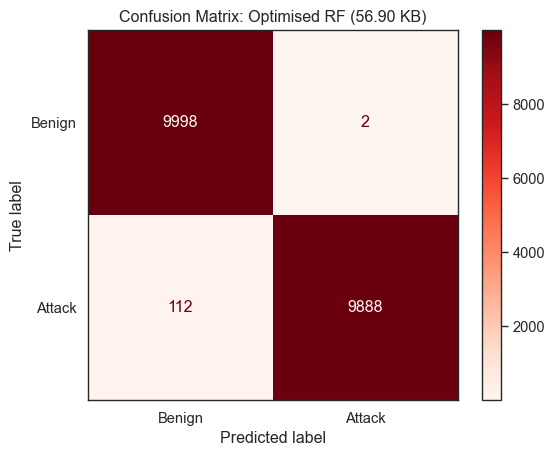

In [46]:
y_pred_optimised = rf_optimised.predict(X_test_meaningful_scaled)
print("--- Optimised RF (5 Trees, Depth 9) Performance ---")
print(classification_report(y_test_meaningful, y_pred_optimised))

# Check the confusion matrix again
ConfusionMatrixDisplay.from_predictions(y_test_meaningful, y_pred_optimised, display_labels=['Benign', 'Attack'], cmap='Reds')
plt.title(f"Confusion Matrix: Optimised RF ({optimised_size_kb:.2f} KB)")
plt.show()

In [48]:
# Capture Scaler Parameters (Crucial for C++ Implementation)
print("--- SCALER PARAMETERS ---")
for i, feature in enumerate(meaningful_features['feature'].tolist()):
    print(f"Feature: {feature}")

    print(f"  Median (Center): {scaler_meaningful.center_[i]}")
    print(f"  Interquartile Range (Scale): {scaler_meaningful.scale_[i]}")
    print("-" * 30)

--- SCALER PARAMETERS ---
Feature: dest_port
  Median (Center): 23.0
  Interquartile Range (Scale): 8058.0
------------------------------
Feature: avg_packet_size_source
  Median (Center): 40.0
  Interquartile Range (Scale): 20.0
------------------------------
Feature: source_port
  Median (Center): 41427.5
  Interquartile Range (Scale): 21923.0
------------------------------
Feature: throughput
  Median (Center): 0.0
  Interquartile Range (Scale): 57.966870001565105
------------------------------
Feature: inter_arrival_time
  Median (Center): 5.0067901611328125e-06
  Interquartile Range (Scale): 0.0002338886260986328
------------------------------


Convert to c++

In [49]:
code = m2c.export_to_c(rf_optimised)

with open("models/optimised_rf_model.h", "w") as f:
    f.write(code)

print("C++ Header File Generated: optimised_rf_model.h")

C++ Header File Generated: optimised_rf_model.h


Convert unscaled test samples to C++ so scaling + inference can be tested

In [59]:
# Grab 5 of each from the UN-scaled dataframe
raw_attacks = df_balanced[df_balanced['is_attack'] == 1][meaningful_features['feature'].tolist()].head(5).values
raw_benign = df_balanced[df_balanced['is_attack'] == 0][meaningful_features['feature'].tolist()].head(5).values

print("double raw_samples[10][5] = {")
for row in list(raw_attacks) + list(raw_benign):
    print("  {" + ", ".join(map(str, row)) + "},")
print("};")

double raw_samples[10][5] = {
  {37215.0, 40.0, 5526.0, 0.0, 0.0002498626708984375},
  {8081.0, 40.0, 24159.0, 637450.1992031874, 0.0010018348693847656},
  {23.0, 60.0, 58196.0, 114.35033129832097, 5.9604644775390625e-06},
  {23.0, 60.0, 49090.0, 115.79278495156966, 6.9141387939453125e-06},
  {62336.0, 0.0, 1499.0, 0.0, -4.999948024749756},
  {23.0, 40.0, 54580.0, 0.0, 0.00021791458129882812},
  {23.0, 60.0, 60172.0, 0.0, 3.0994415283203125e-06},
  {23.0, 60.0, 46648.0, 0.0, 0.0002231597900390625},
  {23.0, 60.0, 52034.0, 57.999145479256605, 0.0004930496215820312},
  {23.0, 40.0, 52458.0, 0.0, 1.9073486328125e-06},
};


Convert scaled test samples to C++ so a larger sample set can be used for inference testing

In [54]:
# Select 500 random samples from the scaled test set
test_samples = X_test_meaningful_scaled[:500]
test_labels = y_test[:500].tolist()

# Print test features as C++ array
print("double large_test_set[500][5] = {")
for row in test_samples:
    print("  {" + ", ".join(map(str, row)) + "},")
print("};")



double large_test_set[500][5] = {
  {-0.00012410027302060066, 0.0, 0.7392008393011905, 0.0, 1.0305810397553516},
  {0.0, 1.0, 0.8601240706107741, 0.0, 0.0},
  {0.0, 1.0, 0.15018473749030697, 0.9920130291036773, 474.27217125382265},
  {4.615537354182179, 0.0, -0.2431464671805866, 0.0, -0.012232415902140673},
  {0.0, 1.0, -0.12596359987228026, 0.0, -0.013251783893985729},
  {0.0, 1.0, 0.3214204260365826, 0.0, -0.00815494393476045},
  {0.0, 1.0, 0.2681430461159513, 0.9936758096438862, 0.00815494393476045},
  {0.0, 0.0, -1.3969119189891894, 0.0, -0.009174311926605505},
  {0.0, 1.0, -0.20067965150754916, 0.0, -0.009174311926605505},
  {0.0, 0.0, 1.0031701865620581, 690049.3333333334, -0.004077471967380225},
  {0.0, 0.0, -1.3969119189891894, 0.0, -0.009174311926605505},
  {4.615537354182179, 0.0, -0.13946540163298818, 0.0, 0.0},
  {0.0071978158351948375, 0.0, -1.40206632303973, 0.0, -0.0050968399592252805},
  {4.615537354182179, 0.0, -1.6376180267299183, 0.0, 1.0519877675840978},
  {0.0, 1.0

In [60]:
# Print test labels as C++ integer array
print("int true_labels[500] = {")
print("  " + ", ".join(map(str, [int(x) for x in test_labels])))
print("};")

int true_labels[500] = {
  1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0

Plot one of the trees

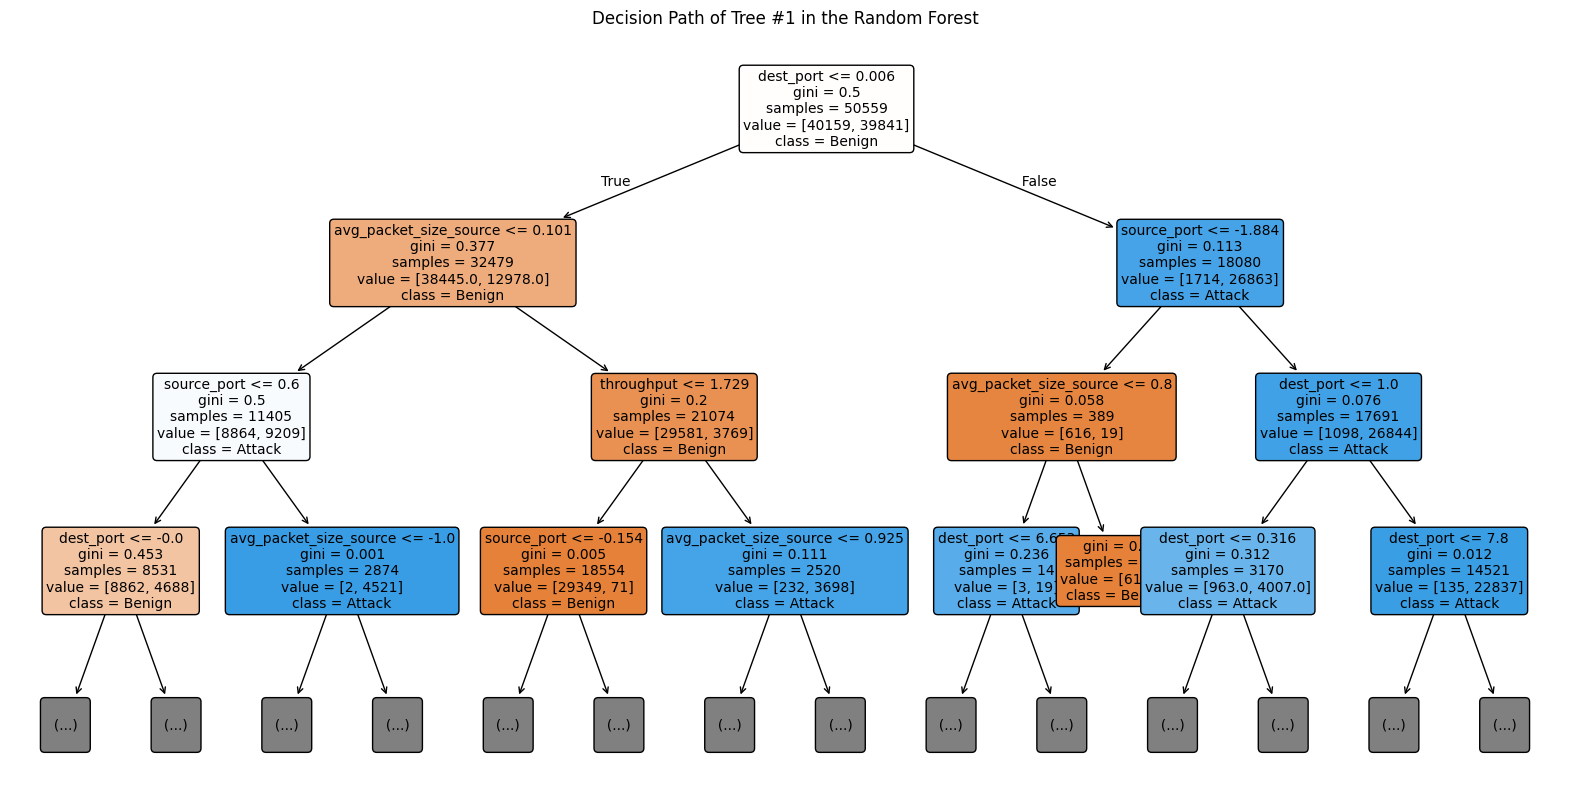

In [57]:
plt.figure(figsize=(20, 10))
plot_tree(rf_optimised.estimators_[0],
          feature_names=X_meaningful.columns,
          class_names=['Benign', 'Attack'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3) # Limiting depth to 3 for the diagram so it's readable
plt.title("Decision Path of Tree #1 in the Random Forest")
plt.savefig("graphs/decision_tree_logic.pdf", bbox_inches='tight')
plt.show()